## FD001 Data Preparation and Exploratory Degradation Analysis

This notebook performs the initial preparation and exploratory analysis of the NASA C‑MAPSS FD001 turbofan engine dataset. The objectives are to construct a clean analytical dataset, define a Remaining Useful Life (RUL) target, and examine how operating conditions and sensor measurements evolve across engine life cycles.

The analysis in this notebook provides the foundation for subsequent modeling by identifying data quality issues, summarizing the RUL distribution, and highlighting sensor patterns associated with degradation.

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# 1. Download the zip file from GitHub into /content
!wget -O CMAPSSData.zip "https://github.com/sudhakaran-srinivasan/intelligent-predictive-maintenance/raw/main/datasets/raw/CMAPSSData.zip"

# 2. Unzip into a folder
!unzip -o CMAPSSData.zip -d /content/cmapss_data

--2026-07-19 14:51:15--  https://github.com/sudhakaran-srinivasan/intelligent-predictive-maintenance/raw/main/datasets/raw/CMAPSSData.zip
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/sudhakaran-srinivasan/intelligent-predictive-maintenance/main/datasets/raw/CMAPSSData.zip [following]
--2026-07-19 14:51:15--  https://raw.githubusercontent.com/sudhakaran-srinivasan/intelligent-predictive-maintenance/main/datasets/raw/CMAPSSData.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12425978 (12M) [application/zip]
Saving to: ‘CMAPSSData.zip’

CMAPSSData.zip      100%[===================>]  11.85M 

## Dataset Overview

This section introduces the NASA C‑MAPSS dataset used in the project and focuses on the FD001 training subset selected for initial analysis. The compressed archive is extracted, the available files are inspected, and the FD001 training data is loaded into a pandas DataFrame for initial shape, column, and sample row inspection.

In [22]:
train_fd001_path = "/content/cmapss_data/train_FD001.txt"

train_fd001 = pd.read_csv(
    train_fd001_path,
    sep=r"\s+",
    header=None
)

print("Shape:", train_fd001.shape)
train_fd001.head()

Shape: (20631, 26)


,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## Data Loading and Column Labeling

The raw FD001 training file is imported without header names, so descriptive column labels are assigned to improve clarity and interpretability. The resulting table includes an engine identifier, cycle count, three operating settings, and 21 sensor measurements, along with any derived fields added later in the analysis (such as maximum cycle and RUL).

In [23]:
# 1. Assign column names for FD001
n_cols = train_fd001.shape[1]
print("Number of columns in raw data:", n_cols)

# Columns
if n_cols != 26:
    raise ValueError(f"Unexpected number of columns: {n_cols} (expected 26 for FD001)")

train_fd001.columns = (
    ["engine_id", "cycle", "setting1", "setting2", "setting3"]
    + [f"sensor{i}" for i in range(1, 22)]
)

# Quick look
train_fd001.head()
train_fd001.columns

Number of columns in raw data: 26


Index(['engine_id', 'cycle', 'setting1', 'setting2', 'setting3', 'sensor1',
       'sensor2', 'sensor3', 'sensor4', 'sensor5', 'sensor6', 'sensor7',
       'sensor8', 'sensor9', 'sensor10', 'sensor11', 'sensor12', 'sensor13',
       'sensor14', 'sensor15', 'sensor16', 'sensor17', 'sensor18', 'sensor19',
       'sensor20', 'sensor21'],
      dtype='object')

## Remaining Useful Life (RUL) Target

The dataset is extended with a Remaining Useful Life (RUL) target for each engine‑cycle observation. This target is computed by identifying the final recorded cycle for each engine and subtracting the current cycle from that maximum value, so that RUL represents the number of cycles remaining before failure.

This transformation converts the run‑to‑failure trajectories into a supervised learning dataset in which each row corresponds to a specific engine state paired with its remaining life.

In [24]:
# 1. Compute max cycle per engine
max_cycles = (
    train_fd001.groupby("engine_id")["cycle"]
    .max()
    .reset_index()
    .rename(columns={"cycle": "max_cycle"})
)

# 2. Merge back to main DataFrame
train_fd001 = train_fd001.merge(max_cycles, on="engine_id", how="left")

# 3. Remaining Useful Life (RUL) at each cycle
train_fd001["RUL"] = train_fd001["max_cycle"] - train_fd001["cycle"]

# 4. Quick look
train_fd001[["engine_id", "cycle", "max_cycle", "RUL"]].head()

,engine_id,cycle,max_cycle,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187


## Data Quality, RUL Distribution, and Sensor Degradation

**Data quality.** Performs an initial exploratory review of dataset quality and degradation behavior by examining data types, checking for missing values, and identifying sensors that display no variation, since non‑informative variables are unlikely to contribute to predictive performance.

**RUL distribution.** Examines the distribution of Remaining Useful Life values to understand how observations are concentrated across different stages of engine life and how much data is available near end‑of‑life versus earlier cycles.

**Sensor degradation.** Plots selected sensor trajectories across cycles for a set of representative engines in order to visualize how sensor readings evolve as degradation progresses and to highlight sensors that exhibit clearer monotonic trends.

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 28 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   setting1   20631 non-null  float64
 3   setting2   20631 non-null  float64
 4   setting3   20631 non-null  float64
 5   sensor1    20631 non-null  float64
 6   sensor2    20631 non-null  float64
 7   sensor3    20631 non-null  float64
 8   sensor4    20631 non-null  float64
 9   sensor5    20631 non-null  float64
 10  sensor6    20631 non-null  float64
 11  sensor7    20631 non-null  float64
 12  sensor8    20631 non-null  float64
 13  sensor9    20631 non-null  float64
 14  sensor10   20631 non-null  float64
 15  sensor11   20631 non-null  float64
 16  sensor12   20631 non-null  float64
 17  sensor13   20631 non-null  float64
 18  sensor14   20631 non-null  float64
 19  sensor15   20631 non-null  float64


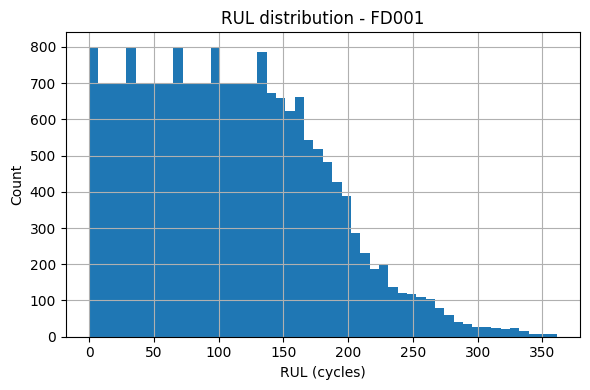

In [25]:
# 1. Basic info and missing values
print("Data info:")
train_fd001.info()

print("\nMissing values per column:")
print(train_fd001.isna().sum())

# 2. Sensors with no or limited variation
sensor_cols = [c for c in train_fd001.columns if c.startswith("sensor")]
constant_sensors = [
    col for col in sensor_cols
    if train_fd001[col].nunique() <= 1
]
print("\nConstant sensors (no variation):", constant_sensors)

# 3. RUL distribution
plt.figure(figsize=(6, 4))
train_fd001["RUL"].hist(bins=50)
plt.title("RUL distribution - FD001")
plt.xlabel("RUL (cycles)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Exploratory Data Analysis: Quality, RUL, and Degradation

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 28 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   setting1   20631 non-null  float64
 3   setting2   20631 non-null  float64
 4   setting3   20631 non-null  float64
 5   sensor1    20631 non-null  float64
 6   sensor2    20631 non-null  float64
 7   sensor3    20631 non-null  float64
 8   sensor4    20631 non-null  float64
 9   sensor5    20631 non-null  float64
 10  sensor6    20631 non-null  float64
 11  sensor7    20631 non-null  float64
 12  sensor8    20631 non-null  float64
 13  sensor9    20631 non-null  float64
 14  sensor10   20631 non-null  float64
 15  sensor11   20631 non-null  float64
 16  sensor12   20631 non-null  float64
 17  sensor13   20631 non-null  float64
 18  sensor14   20631 non-null  float64
 19  sensor15   20631 non-null  float64


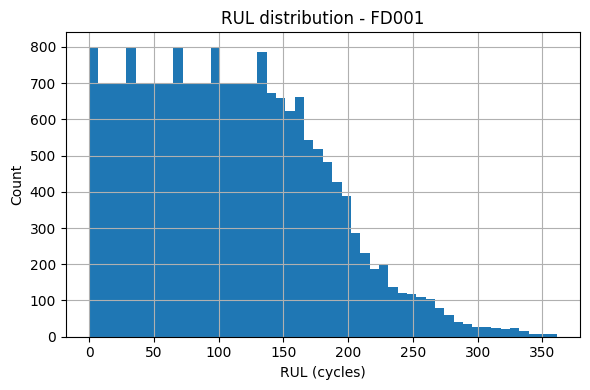

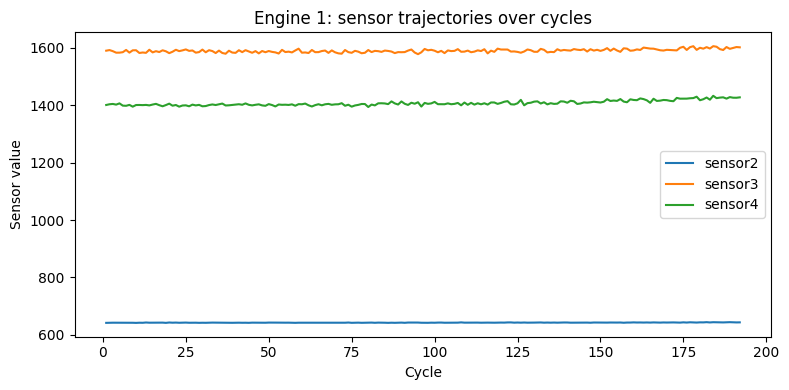

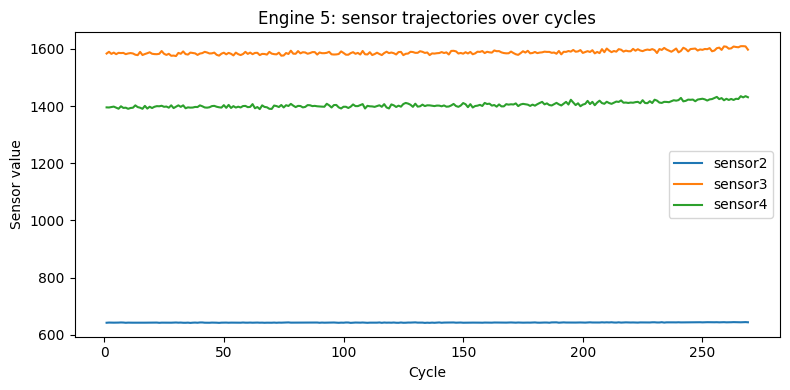

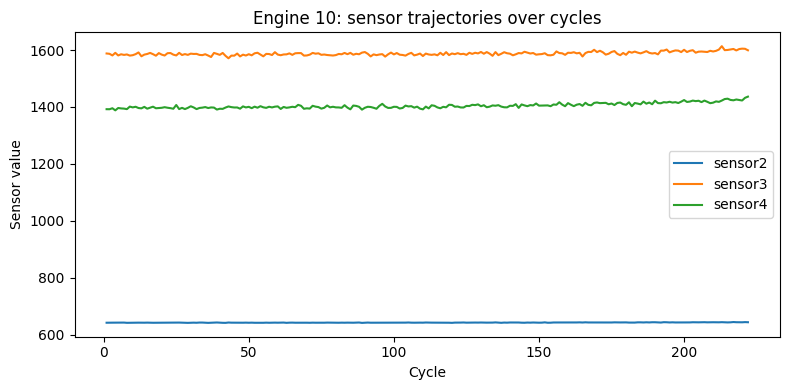

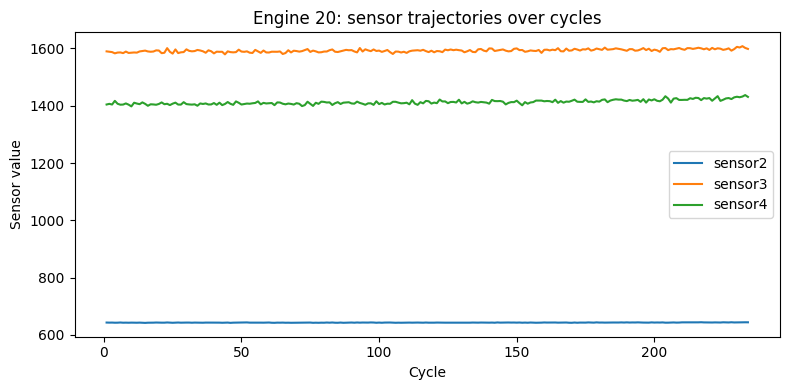

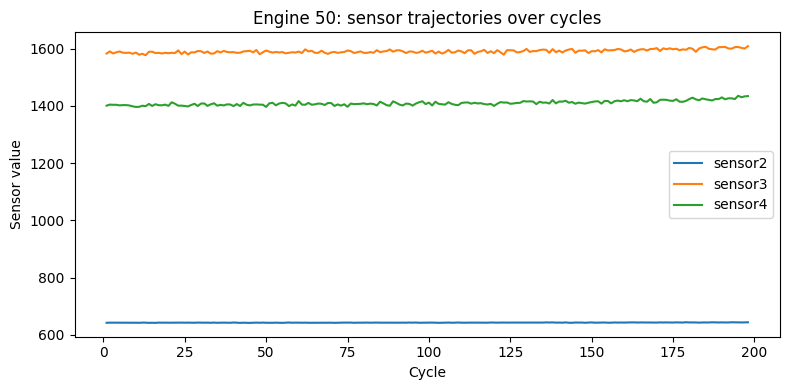

In [26]:
# 1. Quality checks
print("Data info:")
train_fd001.info()

print("\nMissing values per column:")
print(train_fd001.isna().sum())

# Sensors (no variation across all rows)
sensor_cols = [c for c in train_fd001.columns if c.startswith("sensor")]
constant_sensors = [
    col for col in sensor_cols
    if train_fd001[col].nunique() <= 1
]
print("\nConstant sensors (no variation):", constant_sensors)

# 2. RUL distribution
plt.figure(figsize=(6, 4))
train_fd001["RUL"].hist(bins=50)
plt.title("RUL distribution - FD001")
plt.xlabel("RUL (cycles)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 3. Sensor changes for selected engines and sensors
engines_to_plot = [1, 5, 10, 20, 50]
sensors_to_plot = ["sensor2", "sensor3", "sensor4"]

for eng in engines_to_plot:
    df_eng = train_fd001[train_fd001["engine_id"] == eng]
    plt.figure(figsize=(8, 4))
    for s in sensors_to_plot:
        plt.plot(df_eng["cycle"], df_eng[s], label=s)
    plt.title(f"Engine {eng}: sensor trajectories over cycles")
    plt.xlabel("Cycle")
    plt.ylabel("Sensor value")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Sensor–RUL Correlation Analysis

Correlation of sensors with RUL (sorted):
sensor12    0.671983
sensor7     0.657223
sensor21    0.635662
sensor20    0.629428
sensor6    -0.128348
sensor14   -0.306769
sensor9    -0.390102
sensor13   -0.562569
sensor8    -0.563968
sensor3    -0.584520
sensor17   -0.606154
sensor2    -0.606484
sensor15   -0.642667
sensor4    -0.678948
sensor11   -0.696228
sensor1          NaN
sensor5          NaN
sensor10         NaN
sensor16         NaN
sensor18         NaN
sensor19         NaN
Name: RUL, dtype: float64


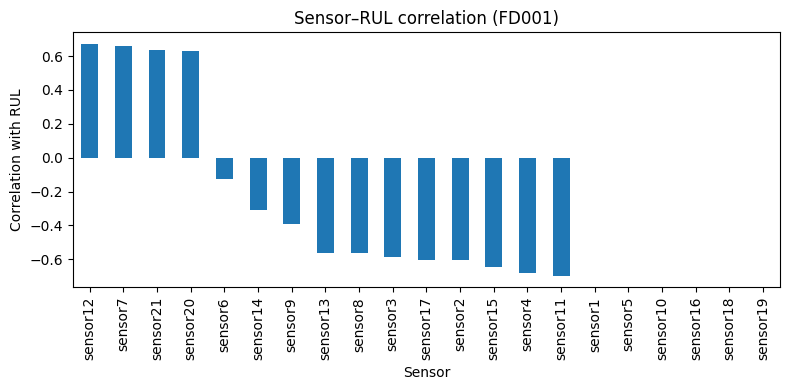

In [27]:
# 1. Correlation of each sensor with RUL
sensor_cols = [c for c in train_fd001.columns if c.startswith("sensor")]

corr = train_fd001[["RUL"] + sensor_cols].corr()

# Sort sensors by correlation with RUL
corr_with_rul = corr["RUL"].drop("RUL").sort_values(ascending=False)

print("Correlation of sensors with RUL (sorted):")
print(corr_with_rul)

# 2. Bar chart of correlations
plt.figure(figsize=(8, 4))
corr_with_rul.plot(kind="bar")
plt.title("Sensor–RUL correlation (FD001)")
plt.xlabel("Sensor")
plt.ylabel("Correlation with RUL")
plt.tight_layout()
plt.show()

In [28]:
top_k = 5
top_sensors = corr_with_rul.abs().sort_values(ascending=False).head(top_k)
print(f"\nTop {top_k} sensors by |correlation| with RUL:")
print(top_sensors)


Top 5 sensors by |correlation| with RUL:
sensor11    0.696228
sensor4     0.678948
sensor12    0.671983
sensor7     0.657223
sensor15    0.642667
Name: RUL, dtype: float64


## Sensor Distribution and Variability

This section summarizes the distributional behavior of selected sensor variables that appear most relevant to Remaining Useful Life (RUL). By examining their spread, central tendency, and overall shape, the analysis highlights skewness, unusual values, and differences in measurement behavior across sensors that may influence how well they capture degradation.

Summary statistics for top correlated sensors:
           sensor11       sensor4      sensor12       sensor7      sensor15
count  20631.000000  20631.000000  20631.000000  20631.000000  20631.000000
mean      47.541168   1408.933782    521.413470    553.367711      8.442146
std        0.267087      9.000605      0.737553      0.885092      0.037505
min       46.850000   1382.250000    518.690000    549.850000      8.324900
25%       47.350000   1402.360000    520.960000    552.810000      8.414900
50%       47.510000   1408.040000    521.480000    553.440000      8.438900
75%       47.700000   1414.555000    521.950000    554.010000      8.465600
max       48.530000   1441.490000    523.380000    556.060000      8.584800


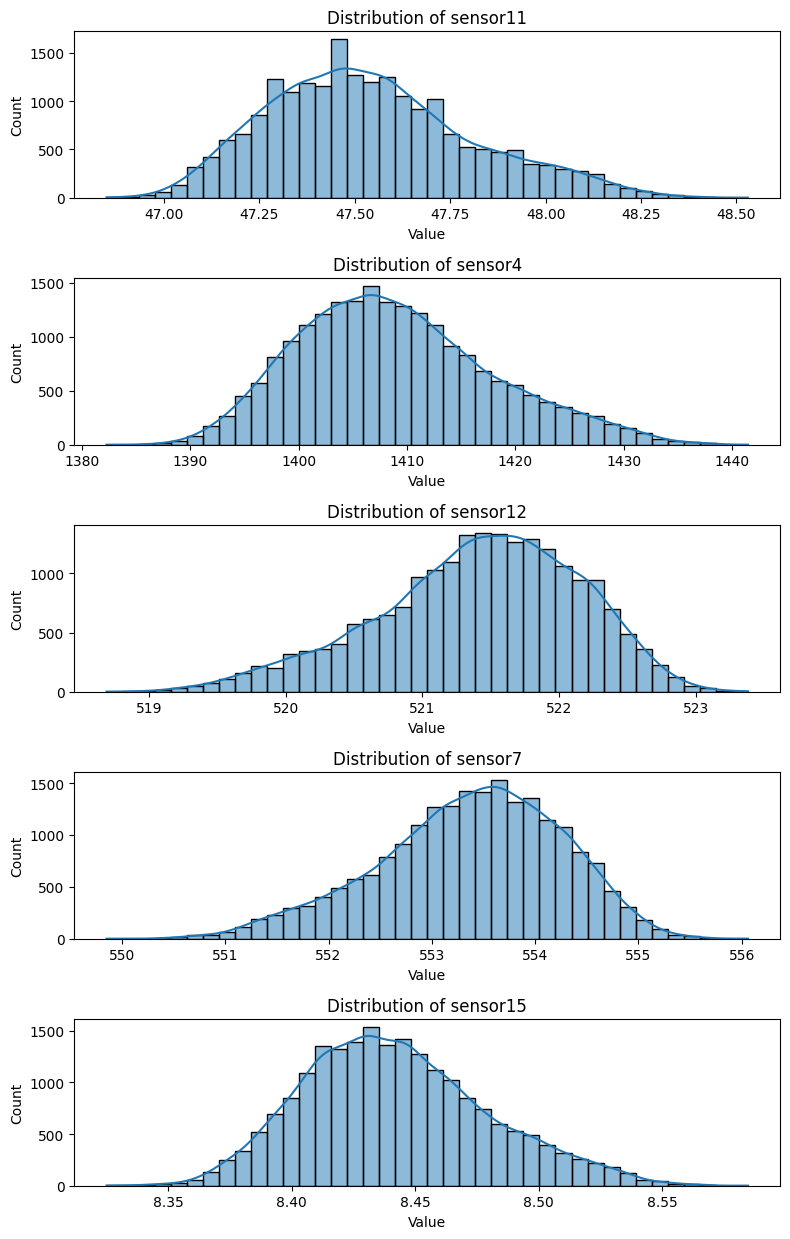

In [29]:
# Top 5 sensors by absolute correlation with RUL
top_sensors = (
    corr_with_rul.abs()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

print("Summary statistics for top correlated sensors:")
print(train_fd001[top_sensors].describe())

# Visualize distributions for top sensors
fig, axes = plt.subplots(len(top_sensors), 1, figsize=(8, 2.5 * len(top_sensors)))

for ax, s in zip(axes, top_sensors):
    sns.histplot(train_fd001[s], bins=40, kde=True, ax=ax)
    ax.set_title(f"Distribution of {s}")
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

## Correlation Heatmap for RUL, Settings, and Key Sensors

This section visualizes the correlation structure among the Remaining Useful Life (RUL) target, the operating settings, and a selected group of sensor variables using a heatmap.

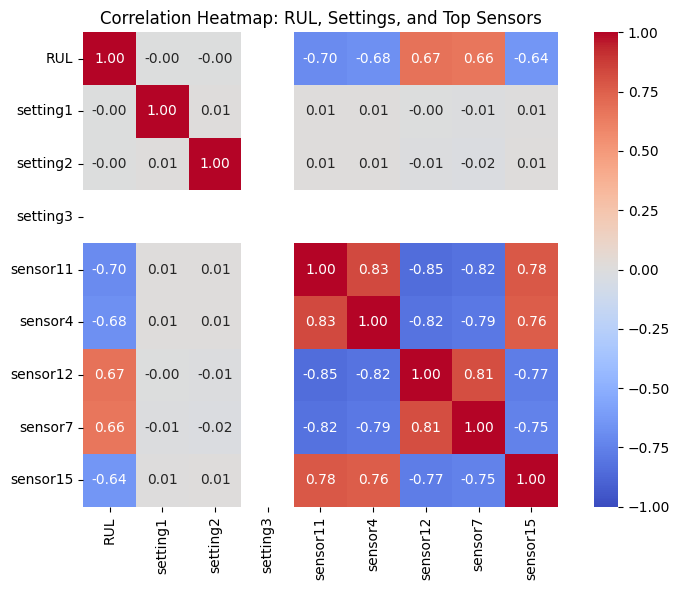

In [30]:
# Correlation matrix for settings, RUL, and top sensors
heatmap_cols = ["RUL", "setting1", "setting2", "setting3"] + top_sensors
corr_matrix = train_fd001[heatmap_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    square=True
)
plt.title("Correlation Heatmap: RUL, Settings, and Top Sensors")
plt.tight_layout()
plt.show()

## Operating Settings Across Cycles

This section examines how the operating settings vary across engine cycles and how those settings relate to degradation over time. Since operating conditions can influence both sensor behavior and failure progression, they are reviewed alongside the sensor signals themselves to understand whether observed degradation patterns are driven by underlying health, changing operating regimes, or both.

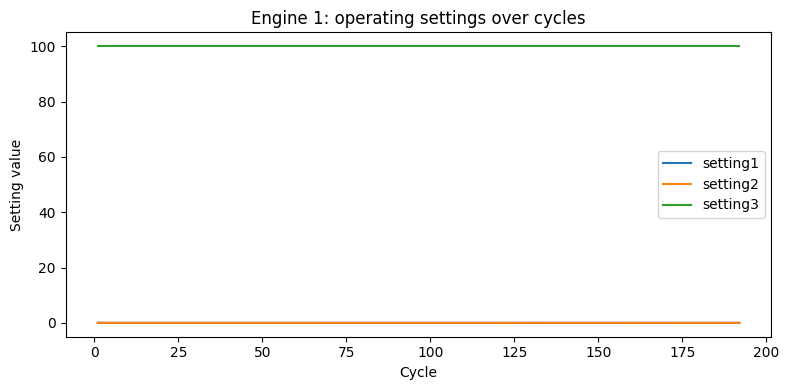

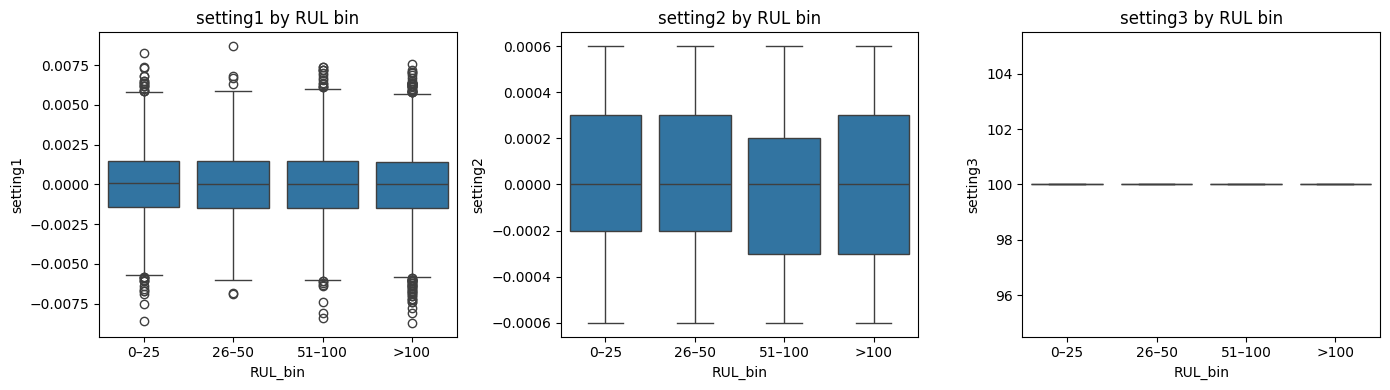

In [31]:
settings_to_plot = ["setting1", "setting2", "setting3"]

# Settings over cycles for one representative engine
eng = 1
df_eng = train_fd001[train_fd001["engine_id"] == eng]

plt.figure(figsize=(8, 4))
for s in settings_to_plot:
    plt.plot(df_eng["cycle"], df_eng[s], label=s)
plt.title(f"Engine {eng}: operating settings over cycles")
plt.xlabel("Cycle")
plt.ylabel("Setting value")
plt.legend()
plt.tight_layout()
plt.show()

# Boxplots by RUL bins
train_fd001["RUL_bin"] = pd.cut(
    train_fd001["RUL"],
    bins=[0, 25, 50, 100, train_fd001["RUL"].max()],
    labels=["0–25", "26–50", "51–100", ">100"]
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, s in zip(axes, settings_to_plot):
    sns.boxplot(data=train_fd001, x="RUL_bin", y=s, ax=ax)
    ax.set_title(f"{s} by RUL bin")
plt.tight_layout()
plt.show()

## Pairwise Relationships

This section uses a small random sample of engine‑cycle observations to visualize pairwise relationships among key variables in the FD001 dataset. The pairplot highlights potential non‑linear patterns, clustering behavior, and separation structures that may not be evident from summary statistics or simple correlation measures, and helps identify combinations of settings and sensor values that align with different RUL ranges.


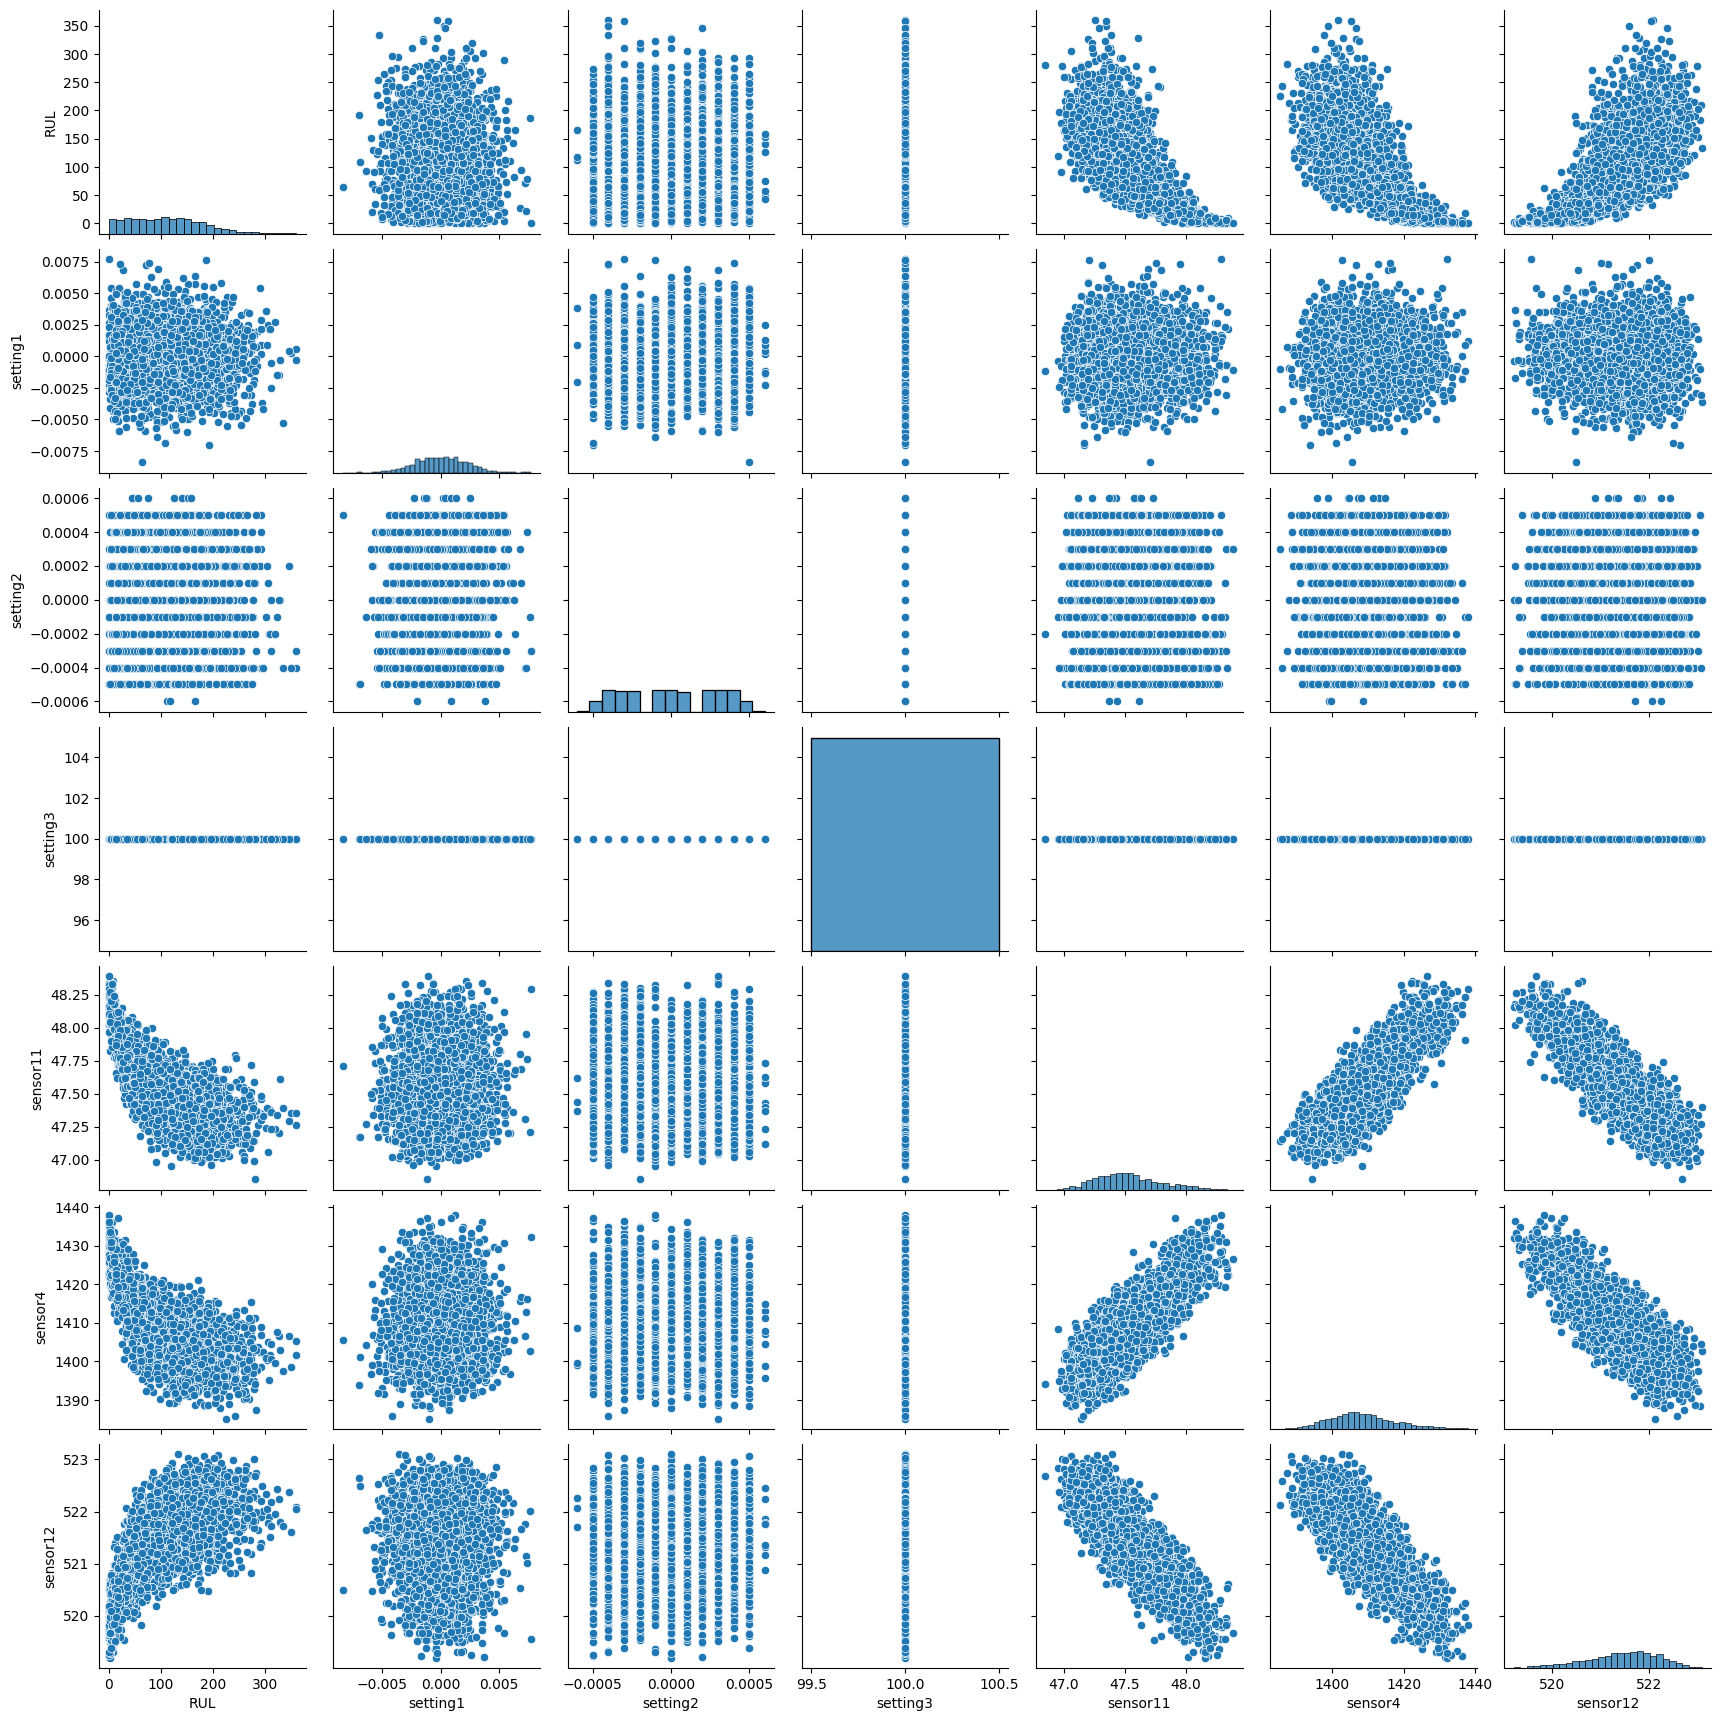

In [32]:
sample_cols = ["RUL", "setting1", "setting2", "setting3"] + top_sensors[:3]

sample_df = train_fd001[sample_cols].sample(
    n=min(3000, len(train_fd001)),
    random_state=42
)

sns.pairplot(sample_df, diag_kind="hist")
plt.show()

## Save Prepared FD001 Dataset

Exports the labeled FD001 training data with the constructed RUL target to a CSV file. This processed dataset will be used as input for subsequent modeling notebooks.

In [ ]:
# Save processed FD001 (with RUL)
train_fd001.to_csv('/content/fd001_train_with_rul.csv', index=False)

## EDA Summary

The results of this exploratory analysis indicate that the FD001 subset provides a suitable foundation for predictive maintenance modeling. The dataset contains complete engine trajectories, a clearly defined Remaining Useful Life (RUL) target, and several sensor measurements that appear to capture degradation patterns over time.

The analysis also shows that not all variables contribute equally. Some sensors remain effectively constant across observations, whereas others demonstrate stronger directional trends and larger correlations with RUL. These early findings support a more targeted modeling strategy in which non‑informative variables are reduced, allowing subsequent models to focus on the most relevant operating conditions and sensor signals when predicting RUL and identifying high‑risk engines. All model building, hyperparameter tuning, and comparison to state‑of‑the‑art approaches are handled in separate modeling notebooks that build on this prepared dataset.